In [ ]:
!pip install gdown
!gdown --id 1Oct5tvQbWhL8hknVMrI5Vc957xbU_Nua --output /content/Mask_data.zip

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Oct5tvQbWhL8hknVMrI5Vc957xbU_Nua
From (redirected): https://drive.google.com/uc?id=1Oct5tvQbWhL8hknVMrI5Vc957xbU_Nua&confirm=t&uuid=bfc23431-947b-48e2-baef-39f5e2f5de68
To: /content/Mask_data.zip
100% 78.8M/78.8M [00:00<00:00, 194MB/s]


# 이미지 데이터 설정

In [ ]:
import os
import zipfile

local_zip = '/content/Mask_data.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')

zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
# 훈련용 디렉토리
train_dir = '/content/train'

# 검증용 디렉토리
validation_dir = '/content/validation'

print(train_dir)
print(validation_dir)

/content/train
/content/validation


In [ ]:
train_withmask_dir = os.path.join(train_dir, 'withmask')
train_withoutmask_dir = os.path.join(train_dir, 'withoutmask')
print(train_withmask_dir)
print(train_withoutmask_dir)

/content/train/withmask
/content/train/withoutmask


In [ ]:
validation_withmask_dir = os.path.join(validation_dir, 'withmask')
validation_withoutmask_dir = os.path.join(validation_dir, 'withoutmask')
print(validation_withmask_dir)
print(validation_withoutmask_dir)

/content/validation/withmask
/content/validation/withoutmask


In [ ]:
train_withmask_fnames = os.listdir(train_withmask_dir)
train_withoutmask_fnames = os.listdir(train_withoutmask_dir)
print(train_withmask_fnames[:5])
print(train_withoutmask_fnames[:5])

['withmask (585).jpg', 'withmask (154).jpg', 'withmask (475).jpg', 'withmask (248).jpg', 'withmask (383).jpg']
['withoutmask (461).jpg', 'withoutmask (543).jpg', 'withoutmask (549).jpg', 'withoutmask (44).jpg', 'withoutmask (175).jpg']


# 데이터 확인

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

nrows, ncols = 4, 4
pic_index = 0
fig = plt.gcf()
fig.set_size_inches(ncols*3, nrows+3)
pic_index += 8

next_withmask_pix = [os.path.join(train_withmask_dir, fname) for fname in train_withmask_fnames[pic_index-8:pic_index]]
next_withoutmask_pix = [os.path.join(train_withoutmask_dir, fname) for fname in train_withoutmask_fnames[pic_index-8:pic_index]]

next_withmask_pix

['/content/train/withmask/withmask (585).jpg',
 '/content/train/withmask/withmask (154).jpg',
 '/content/train/withmask/withmask (475).jpg',
 '/content/train/withmask/withmask (248).jpg',
 '/content/train/withmask/withmask (383).jpg',
 '/content/train/withmask/withmask (258).jpg',
 '/content/train/withmask/withmask (419).jpg',
 '/content/train/withmask/withmask (342).jpg']

<Figure size 1200x700 with 0 Axes>

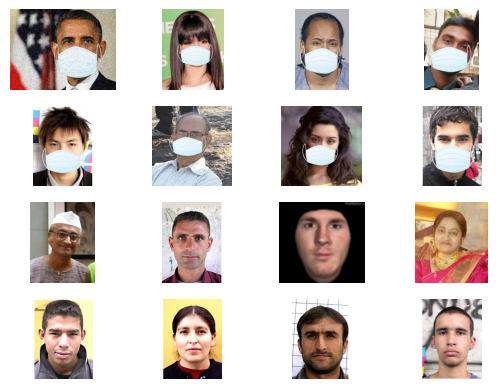

In [ ]:
for i, img_path in enumerate(next_withmask_pix+next_withoutmask_pix):
  sp = plt.subplot(nrows, ncols, i+1)
  sp.axis('Off')
  img = mpimg.imread(img_path)
  plt.imshow(img)
plt.show()

# 데이터 스케일링 및 전처리


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'binary')

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'binary')

Found 1240 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [ ]:
train_generator.class_indices

{'withmask': 0, 'withoutmask': 1}

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, AveragePooling2D, Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(150,150,3)))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 256, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Flatten())
model.add(Dense(518, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer = Adam(1e-4),
              loss = 'binary_crossentropy',
              metrics = ['acc'])

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)                   │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 150, 150, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_20                 │ (None, 75, 75, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 75, 75, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_21                 │ (None, 38, 38, 64)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 38, 38, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_53 (Conv2D)                   │ (None, 38, 38, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_22                 │ (None, 19, 19, 128)         │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_54 (Conv2D)                   │ (None, 19, 19, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_55 (Conv2D)                   │ (None, 19, 19, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_23                 │ (None, 10, 10, 256)         │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 518)                 │      13,261,318 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │             519 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 14,434,093 (55.06 MB)

 Trainable params: 14,434,093 (55.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_generator,
                    epochs = 50,
                    validation_data = validation_generator)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 275ms/step - acc: 0.5965 - loss: 0.6434 - val_acc: 0.9350 - val_loss: 0.2807
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 391ms/step - acc: 0.9336 - loss: 0.2361 - val_acc: 0.9700 - val_loss: 0.0918
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - acc: 0.9469 - loss: 0.1607 - val_acc: 0.9150 - val_loss: 0.1859
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - acc: 0.9575 - loss: 0.1193 - val_acc: 0.9825 - val_loss: 0.0596
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - acc: 0.9738 - loss: 0.0693 - val_acc: 0.9800 - val_loss: 0.0700
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - acc: 0.9778 - loss: 0.0731 - val_acc: 0.9850 - val_loss: 0.0608
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - acc: 0.9775 - loss: 0.0621 - val_acc: 0.9775 - val_loss: 0.0776
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - acc: 0.9790 - loss: 0.0516 - val_acc: 0.9825 - val_loss: 0.0457
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - acc: 0.98

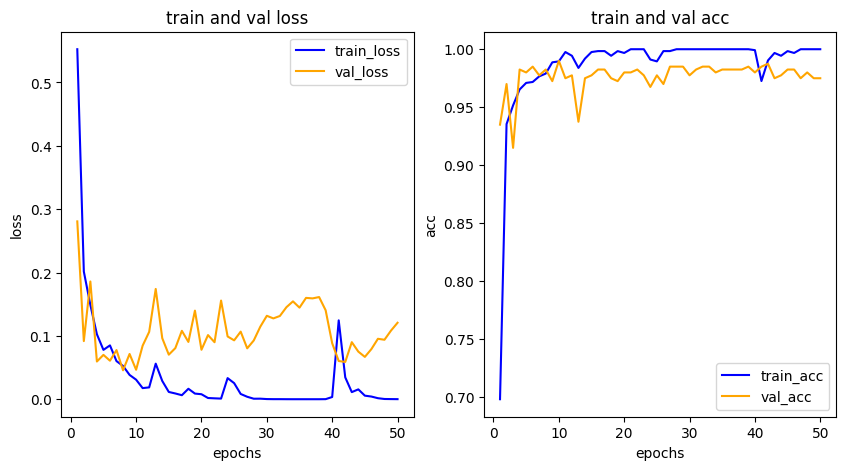

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

# 모델 테스트_1

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def pred(fname):
  img = image.load_img(fname, target_size=(150,150))
  plt.imshow(img)
  x = image.img_to_array(img)/255
  images = np.expand_dims(x, axis=0)
  classes = model.predict(images, batch_size=1)
  print(classes[0])
  if classes[0] < 0.5:
    print(fname.split('/')[-1] + '사진은 마스크를 착용한 사람 입니다.')
  else:
    print(fname.split('/')[-1] + '사진은 마스크를 착용하지 않은 사람입니다..')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[1.340003e-10]
withmask_test_00.jpg사진은 마스크를 착용한 사람 입니다.


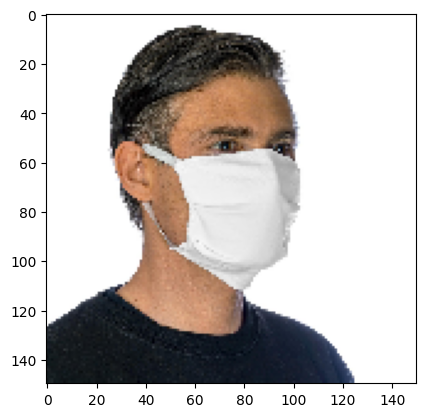

In [ ]:
pred('/content/test/withmask_test_00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[0.9999944]
withoutmask_test_00.jpg사진은 마스크를 착용하지 않은 사람입니다..


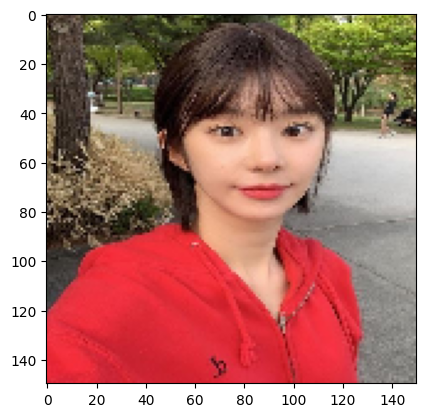

In [ ]:
pred('/content/test/withoutmask_test_00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[1.3831963e-17]
withmask_test_03.jpg사진은 마스크를 착용한 사람 입니다.


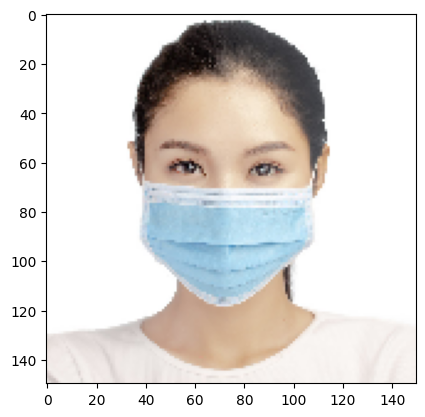

In [ ]:
pred('/content/test/withmask_test_03.jpg')

# 이미지 증식

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(horizontal_flip =True,
                                   zoom_range = 0.2,
                                   width_shift_range = 0.1,
                                   height_shift_range = 0.1,
                                   rotation_range = 30,
                                   fill_mode = 'nearest')
val_datagen = ImageDataGenerator()

# 데이터 스케일링 및 전처리



In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'binary')

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'binary')

Found 1240 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, AveragePooling2D, Dense, Flatten, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(150,150,3)))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 32, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 64, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 128, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Conv2D(filters = 256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters = 256, kernel_size=3, padding='same', activation='relu'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='same'))
model.add(Dropout(0.15))

model.add(Flatten())
model.add(Dense(518, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer = Adam(1e-4),
              loss = 'binary_crossentropy',
              metrics = ['acc'])

In [ ]:
history = model.fit(train_generator,
                    epochs = 50,
                    validation_data = validation_generator)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step - acc: 0.5825 - loss: 0.6570 - val_acc: 0.8175 - val_loss: 0.4733
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - acc: 0.8783 - loss: 0.3108 - val_acc: 0.9625 - val_loss: 0.1052
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - acc: 0.9632 - loss: 0.1140 - val_acc: 0.9725 - val_loss: 0.0755
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - acc: 0.9618 - loss: 0.0956 - val_acc: 0.9775 - val_loss: 0.0558
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - acc: 0.9730 - loss: 0.0785 - val_acc: 0.9675 - val_loss: 0.0650
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - acc: 0.9881 - loss: 0.0379 - val_acc: 0.9750 - val_loss: 0.0867
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - acc: 0.9821 - loss: 0.0464 - val_acc: 0.9750 - val_loss: 0.0621
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - acc: 0.9896 - loss: 0.0294 - val_acc: 0.9675 - val_loss: 0.0861
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - acc: 0.9

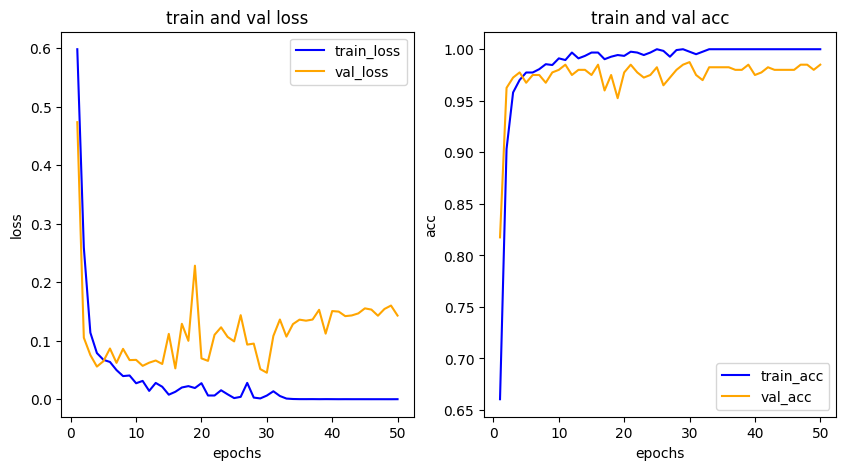

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

# 모델 테스트_2

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def pred(fname):
  img = image.load_img(fname, target_size=(150,150))
  plt.imshow(img)
  x = image.img_to_array(img)/255
  images = np.expand_dims(x, axis=0)
  classes = model.predict(images, batch_size=1)
  print(classes[0])
  if classes[0] < 0.5:
    print(fname.split('/')[-1] + '사진은 마스크를 착용한 사람 입니다.')
  else:
    print(fname.split('/')[-1] + '사진은 마스크를 착용하지 않은 사람입니다..')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
[1.5117133e-05]
withmask_test_01.jpg사진은 마스크를 착용한 사람 입니다.


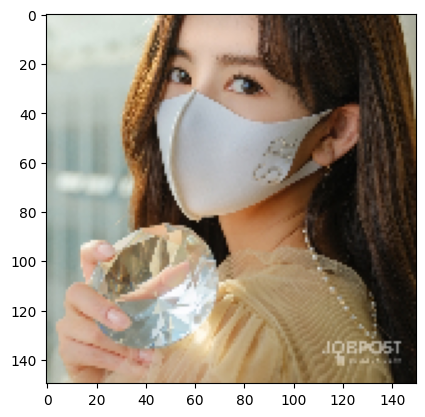

In [ ]:
pred('/content/test/withmask_test_01.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[0.9999987]
withmask_test_04.jpg사진은 마스크를 착용하지 않은 사람입니다..


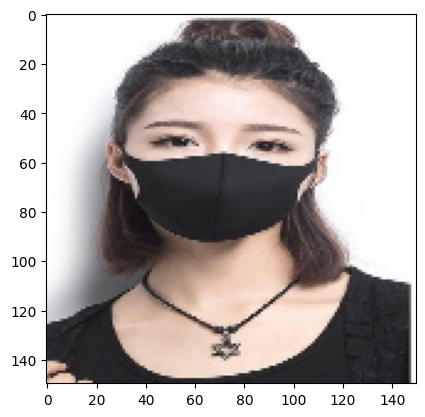

In [ ]:
pred('/content/test/withmask_test_04.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[0.99999833]
withoutmask_test_01.jpg사진은 마스크를 착용하지 않은 사람입니다..


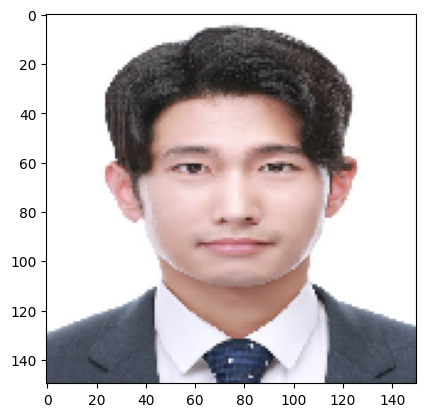

In [ ]:
pred('/content/test/withoutmask_test_01.jpg')

# 전이학습


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

mobilnet2 = MobileNetV2(weights = 'imagenet', input_shape = (150, 150, 3), include_top = False)
mobilnet2.summary()

<ipython-input-124-687a6aa5fa5c>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilnet2 = MobileNetV2(weights = 'imagenet', input_shape = (150, 150, 3), include_top = False)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20            │ (None, 150, 150, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 75, 75, 32)     │            864 │ input_layer_20[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 75, 75, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 75, 75, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 75, 75, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 75, 75, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 75, 75, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 75, 75, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 75, 75, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 75, 75, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 77, 77, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 38, 38, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size = 32,
                                                    target_size = (150, 150),
                                                    class_mode = 'binary')

validation_generator = validation_datagen.flow_from_directory(validation_dir,
                                                              batch_size = 32,
                                                              target_size = (150, 150),
                                                              class_mode = 'binary')

Found 1240 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [ ]:
mobilnet2 = MobileNetV2(weights = 'imagenet', input_shape = (150, 150, 3), include_top = False)
mobilnet2.summary()

model = Sequential()
model.add(Input(shape=(150,150,3)))

model.add(mobilnet2)

model.add(Flatten())
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

<ipython-input-126-5ba54c27db6d>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilnet2 = MobileNetV2(weights = 'imagenet', input_shape = (150, 150, 3), include_top = False)


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21            │ (None, 150, 150, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 75, 75, 32)     │            864 │ input_layer_21[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 75, 75, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 75, 75, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 75, 75, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 75, 75, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 75, 75, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 75, 75, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 75, 75, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 75, 75, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 75, 75, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 77, 77, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 38, 38, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

...

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 32000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 256)                 │       8,192,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,453,834 (39.88 MB)

 Trainable params: 10,419,210 (39.75 MB)

 Non-trainable params: 34,624 (135.25 KB)

In [ ]:
model.compile(optimizer = Adam(1e-4),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['acc'])

In [ ]:
history = model.fit(train_generator,
                    epochs = 50,
                    validation_data = validation_generator)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 79s 849ms/step - acc: 0.7265 - loss: 0.9718 - val_acc: 0.8350 - val_loss: 0.6040
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - acc: 0.9967 - loss: 0.0536 - val_acc: 0.9425 - val_loss: 0.2670
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - acc: 0.9973 - loss: 0.0395 - val_acc: 0.9725 - val_loss: 0.1765
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - acc: 0.9974 - loss: 0.0317 - val_acc: 0.9825 - val_loss: 0.1343
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - acc: 1.0000 - loss: 0.0171 - val_acc: 0.9825 - val_loss: 0.1110
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - acc: 1.0000 - loss: 0.0127 - val_acc: 0.9850 - val_loss: 0.1060
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - acc: 1.0000 - loss: 0.0097 - val_acc: 0.9875 - val_loss: 0.0958
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - acc: 1.0000 - loss: 0.0104 - val_acc: 0.9875 - val_loss: 0.0822
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - a

In [ ]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 32000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 256)                 │       8,192,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,292,256 (119.37 MB)

 Trainable params: 10,419,210 (39.75 MB)

 Non-trainable params: 34,624 (135.25 KB)

 Optimizer params: 20,838,422 (79.49 MB)

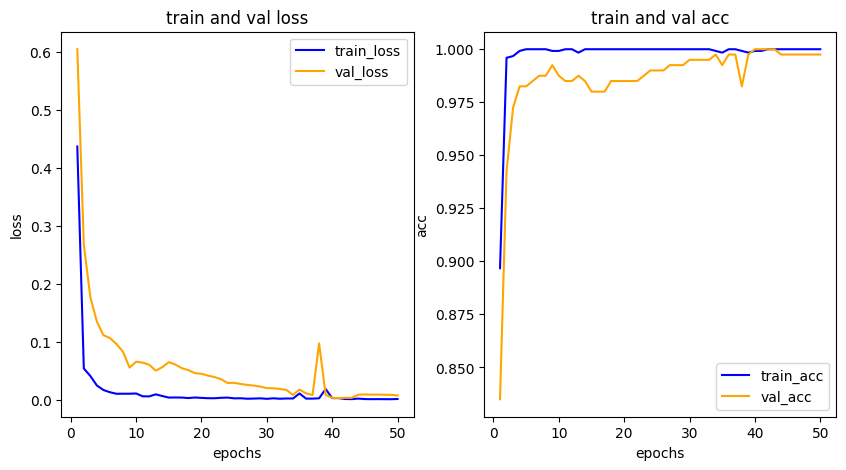

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

# 모델 테스트_3

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def pred(fname):
  img = image.load_img(fname, target_size=(150,150))
  plt.imshow(img)
  x = image.img_to_array(img)/255
  images = np.expand_dims(x, axis=0)
  classes = model.predict(images, batch_size=1)
  print(f"예측 확률: {classes[0][0]:.4f}")
  if classes[0][0] < 0.5:
        print(f"{fname.split('/')[-1]} 사진은 마스크를 착용한 사람입니다.")
  else:
        print(f"{fname.split('/')[-1]} 사진은 마스크를 착용하지 않은 사람입니다.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
예측 확률: 0.9994
withmask_test_03.jpg 사진은 마스크를 착용한 사람입니다.


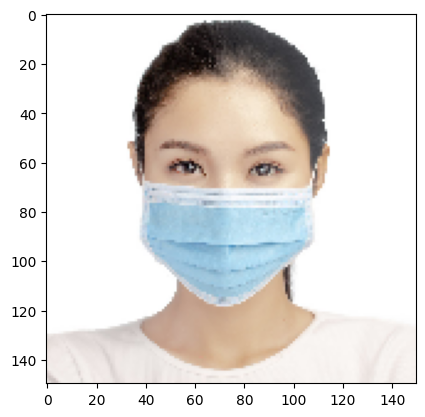

In [ ]:
pred('/content/test/withmask_test_03.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
예측 확률: 0.9335
withmask_test_04.jpg 사진은 마스크를 착용한 사람입니다.


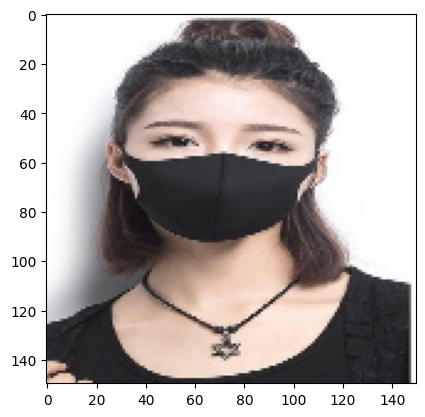

In [ ]:
pred('/content/test/withmask_test_04.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
예측 확률: 0.9995
withmask_test_01.jpg 사진은 마스크를 착용한 사람입니다.


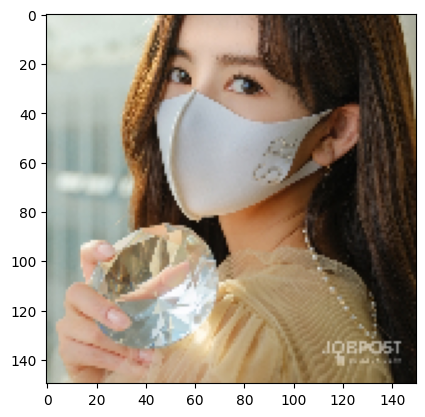

In [ ]:
pred('/content/test/withmask_test_01.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
예측 확률: 0.0000
withoutmask_test_00.jpg 사진은 마스크를 착용하지 않은 사람입니다.


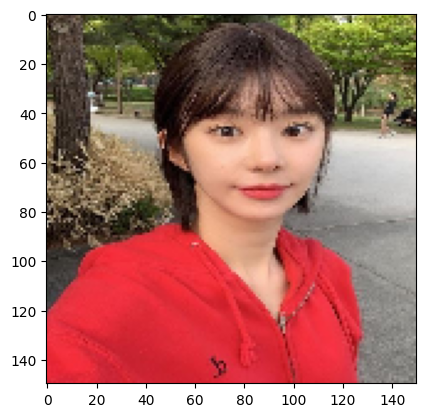

In [ ]:
pred('/content/test/withoutmask_test_00.jpg')